In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [13]:
train_docs = datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_docs = datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.ToTensor())

In [14]:
calasses = train_docs.classes

In [15]:
len(calasses)

10

In [16]:
train = DataLoader(train_docs, batch_size=64, shuffle=True)
test = DataLoader(test_docs, batch_size=64)


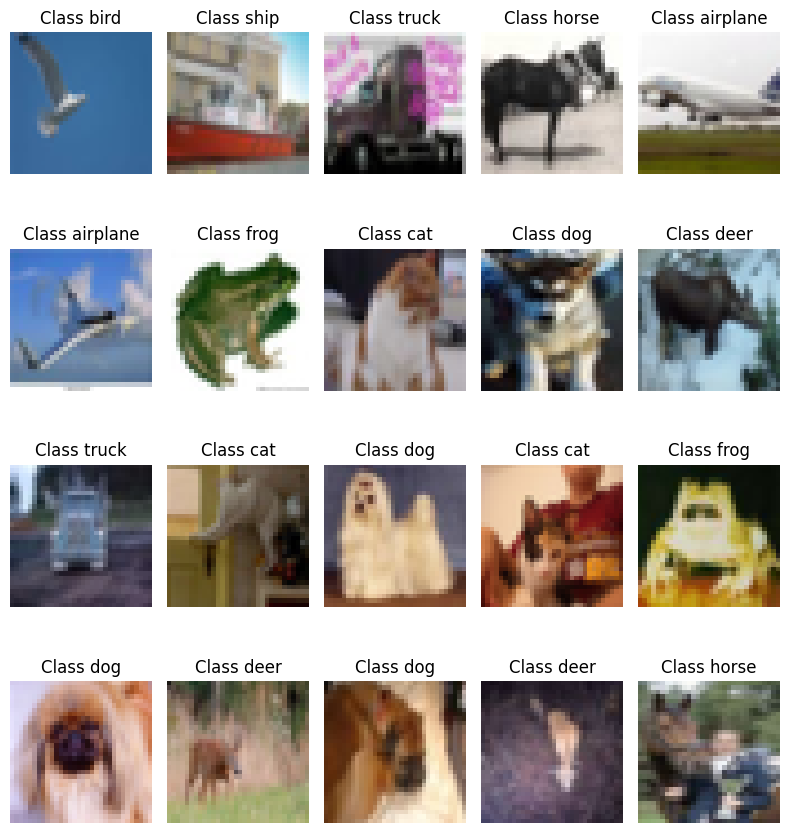

In [17]:
image, label = next(iter(train))
plt.figure(figsize=(8,  10))
for i in range(20):
  plt.subplot(4, 5, i+1)
  plt.imshow(image[i].permute(1, 2, 0))
  plt.title(f'Class {calasses[label[i]]}')
  plt.axis('off')
  plt.tight_layout()
plt.show()

In [18]:
from torch.nn.modules.conv import Conv2d
class CifarClassification(nn.Module):
  def __init__(self):
    super().__init__()
    self.first = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.second = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128 * 4 * 4, 256),
        nn.ReLU(),
        nn.Linear(256, 10)
    )
  def forward(self, x):
    x = self.first(x)
    x = self.second(x)
    return x

In [19]:
class CofarClassification2(nn.Module):
  def __init__(self):
    super().__init__()
    self.first = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
    )
    self.second = nn.Sequential(
        nn.Flatten(),
        nn.Linear(32 * 16 * 16, 256),
        nn.ReLU(),
        nn.Linear(256, 10)
    )
  def forward(self, x):
    x = self.first(x)
    x = self.second(x)
    return x



In [20]:
from torch.nn.modules.pooling import MaxPool2d
class CofarClassification3(nn.Module):
  def __init__(self):
    super().__init__()
    self.first = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(inplace=True),
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),

        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.Conv2d(128, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),

        nn.Conv2d(128, 256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),


        nn.Conv2d(256, 512, kernel_size=3, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Conv2d(512, 512, kernel_size=3, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
        nn.Conv2d(512, 512, kernel_size=3, padding=1),


        nn.Conv2d(512, 1024, kernel_size=3, padding=1),
        nn.BatchNorm2d(1024),
        nn.ReLU(inplace=True),
        nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
        nn.BatchNorm2d(1024),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
        nn.Conv2d(1024, 1024, kernel_size=3, padding=1)
    )
    self.second = nn.Sequential(
        nn.Flatten(),
        nn.Linear(1024 * 1 * 1, 1024),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(1024, 10)
    )
  def forward(self, x):
    x = self.first(x)
    x = self.second(x)
    return x

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [23]:
model = CifarClassification().to(device)
model2 = CofarClassification2().to(device)
model3 = CofarClassification3().to(device)

In [29]:
model_path = 'model_cifar10.pth'


In [31]:
loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss1 = nn.CrossEntropyLoss()
optimizer1 = optim.Adam(model2.parameters(), lr=0.001)
loss2 = nn.CrossEntropyLoss()
optimizer2 = optim.Adam(model3.parameters(), lr=0.001)

In [ ]:
for epoch in range(30):
  model.train()
  total_loss = 0
  for x_bath, y_bath in train:
    x_bath, y_bath = x_bath.to(device), y_bath.to(device)

    y_pred = model(x_bath)
    l = loss(y_pred, y_bath)

    optimizer.zero_grad()
    l.backward()
    optimizer.step()
    total_loss += l.item()

  print(f'Epoch {epoch+1}, Loss: {round(total_loss, 2)}')


In [ ]:
for epoch in range(30):
  model2.train()
  total_loss = 0
  for x_bath, y_bath in train:
    x_bath, y_bath = x_bath.to(device), y_bath.to(device)

    y_pred = model2(x_bath)
    l = loss1(y_pred, y_bath)

    optimizer.zero_grad()
    l.backward()
    optimizer.step()
    total_loss += l.item()

  print(f'Epoch {epoch+1}, Loss: {round(total_loss, 2)}')

In [32]:
for epoch in range(30):
  model3.train()
  total_loss = 0
  for x_bathс, y_bathс in train:
    x_bathс, y_bathс = x_bathс.to(device), y_bathс.to(device)

    y_predс = model3(x_bathс)
    l = loss2(y_predс, y_bathс)

    optimizer2.zero_grad()
    l.backward()
    optimizer2.step()
    total_loss += l.item()

  print(f'Epoch {epoch+1}, Loss: {round(total_loss, 2)}')

Epoch 1, Loss: 1523.86
Epoch 2, Loss: 1226.72
Epoch 3, Loss: 971.74
Epoch 4, Loss: 773.79
Epoch 5, Loss: 639.73
Epoch 6, Loss: 542.64
Epoch 7, Loss: 470.81
Epoch 8, Loss: 408.23
Epoch 9, Loss: 360.66
Epoch 10, Loss: 312.65
Epoch 11, Loss: 273.15
Epoch 12, Loss: 233.27
Epoch 13, Loss: 203.43
Epoch 14, Loss: 173.51
Epoch 15, Loss: 152.24
Epoch 16, Loss: 131.7
Epoch 17, Loss: 126.92
Epoch 18, Loss: 121.79
Epoch 19, Loss: 88.64
Epoch 20, Loss: 80.43
Epoch 21, Loss: 72.94
Epoch 22, Loss: 81.63
Epoch 23, Loss: 61.82
Epoch 24, Loss: 61.94
Epoch 25, Loss: 58.6
Epoch 26, Loss: 81.48
Epoch 27, Loss: 50.47
Epoch 28, Loss: 46.9
Epoch 29, Loss: 43.13
Epoch 30, Loss: 46.21


In [33]:
model_eval = model3.eval()

In [34]:
model3.eval()
correct = 0
total = 0
with torch.no_grad():
  for x_batch, y_batch in test:
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
    y_pred = model3(x_batch)
    pred = torch.max(y_pred, dim=1)
    total += y_batch.size(0)
    correct += (pred.indices == y_batch).sum().item()
accuracy = 100 * correct/total
print(f'Accuracy: {accuracy} %')

Accuracy: 83.56 %


In [35]:
torch.save(model3.state_dict(), 'model_cifar10.pth')